### Download Datasets


In [2]:
import kagglehub
import shutil
import os

path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("Downloaded to:", path)

# Create data folder if it doesn't exist
os.makedirs("data", exist_ok=True)

# Copy CSV to your data folder
for f in os.listdir(path):
    if f.endswith('.csv'):
        shutil.copy(
            os.path.join(path, f),
            'data/telco_churn.csv'
        )
        print("Saved to data/telco_churn.csv")

c:\Users\dell\churn-api\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloaded to: C:\Users\dell\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1
Saved to data/telco_churn.csv


### Load & inspect:

In [3]:
import pandas as pd

df = pd.read_csv('data/telco_churn.csv')
print(f"Shape {df.shape}")
print(f"\nColumns {df.columns.tolist()}")
print("\n First Rows")
df.head()

Shape (7043, 21)

Columns ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

 First Rows


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Check Missing Values

In [23]:
print(f"Data Types {df.dtypes}")
print(f"\nMissing Values:\n {df.isnull().sum()}")
print(f"Churn Distribution \n{df['Churn'].value_counts()}")

Data Types customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing Values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling 

###  Key stats:

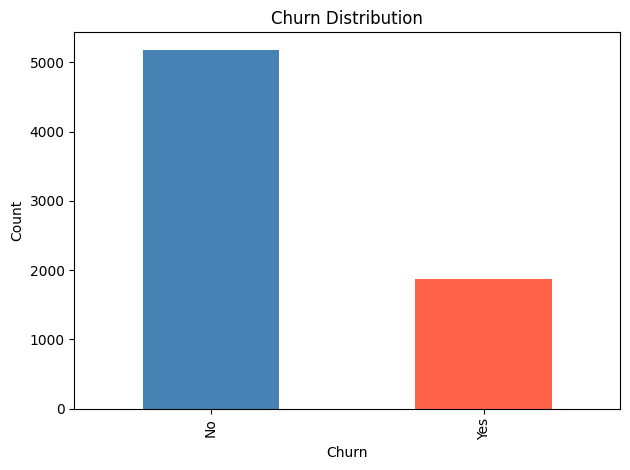

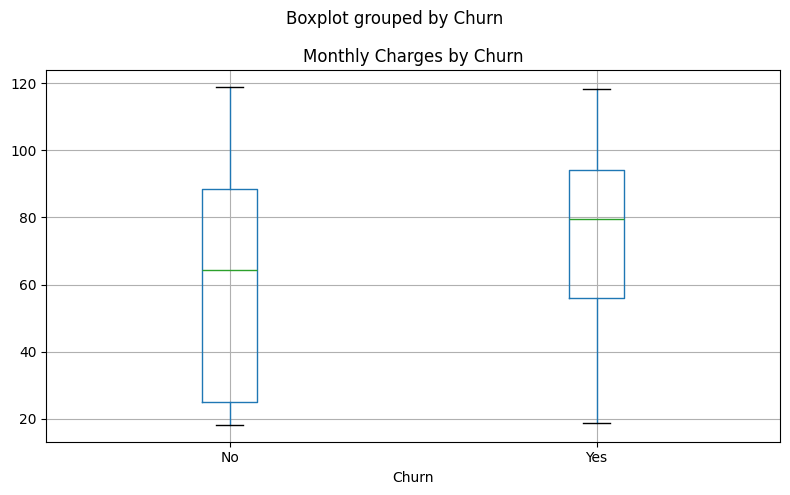

In [7]:
import matplotlib.pyplot as plt

# Churn distribution
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#Monthly Charges by churn
df.boxplot(column='MonthlyCharges', by='Churn', figsize=(8,5))
plt.title("Monthly Charges by Churn")
plt.tight_layout()
plt.show()